# One-dimensional Regression with NNs + ADAM

We want to approximate the following unkown (scalar real-valued) function $f\colon D \subset \mathbb{R} \rightarrow \mathbb{R}$ with a neural network model given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data. 

This notebook uses a simple implementation of a _MLP neural network_ and the _ADAM_ optimizer via the **Optax** repository.

Import dependencies

In [28]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
from jaxtyping import Array, PyTree
import optax
from sklearn.metrics import r2_score

jax.config.update("jax_enable_x64", True)

Define *target function*. For instance, $x \mapsto f(x) = \sqrt{|x|}$

In [29]:
def f_fn(x: Array):
    return jnp.sqrt(jnp.abs(x))
    #return jnp.pow(x, 2)
    #return jnp.exp(x)
    #return jnp.sin(jnp.pi *x)

Get training data by using the discretized 1-dimensional grid as the input

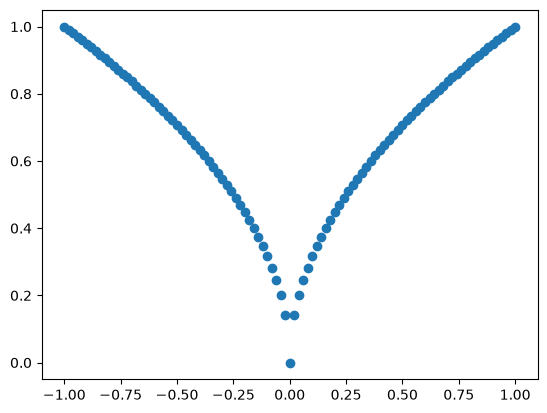

In [30]:
N = 101
x_min, x_max = -1, 1
x_train = jnp.linspace(x_min, x_max, N).reshape(-1, 1)
y_train = f_fn(x_train)
plt.scatter(x_train, y_train);

Build a _multilayer perceptron (MLP)_ feedforward neural network
1. Define method to initialize the model parameters

In [31]:
def init_mlp_params(layer_widths: list) -> list[dict]:
    '''
    Initializes parameters for an MLP and returns them
    wrapped in a list.
    '''
    params = []
    for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
        # weights and bias for each layer
        params.append(
            dict(
                weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2 / n_in),
                biases=np.ones(shape=(n_out,))
            )
        )
    return params

2. Set neural network architecture and initialize parameters

In [32]:
# set input, output and hidden dimensions
d_in, d_hiddens, d_out = 1, [32, 16, 8], 1
params = init_mlp_params([d_in] + d_hiddens + [d_out])

# check shapes
jax.tree_util.tree_map(lambda x: x.shape, params)

[{'biases': (32,), 'weights': (1, 32)},
 {'biases': (16,), 'weights': (32, 16)},
 {'biases': (8,), 'weights': (16, 8)},
 {'biases': (1,), 'weights': (8, 1)}]

3. Define forward method for the model

In [33]:
@jax.jit
def forward(params: list, x: Array, activation=jax.nn.tanh, 
            final_activation=lambda x: x) -> Array:
    '''
    Performs a forward pass
    '''
    *hidden, last = params
    for layer in hidden:
        x = activation(x @ layer['weights'] + layer['biases'])
    return final_activation(x @ last['weights'] + last['biases'])

In [34]:
y_init = forward(params, x_train)

Define MSE loss

In [35]:
@jax.jit
def loss_fn(params: list, x: Array, y: Array) -> Array:
    '''
    Computes the mean square error loss (mse)
    '''
    y_pred = forward(params, x)
    return jnp.mean((y_pred - y)**2)

Define update function method

In [23]:
@jax.jit
def train_step(params: list, opt_state: PyTree, x: Array, y: Array) -> list:
    '''
    Evaluates loss, computes gradients and updates parameters using the chosen optimizer.
    '''
    # evaluate loss and compute gradients
    loss_value, grads = jax.value_and_grad(loss_fn)(params, x, y)

    # compute the updates following the chosen optimizer's rule
    updates, opt_state = opt.update(grads, opt_state)

    # update parameters
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

Define optimizer via optax and initialize parameters

In [24]:
lr = 1e-2
opt = optax.adam(lr)
params = init_mlp_params([d_in] + d_hiddens + [d_out])
opt_state = opt.init(params)

Train

In [25]:
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    params, opt_state, loss_value = train_step(params, opt_state, x_train, y_train)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1-t0))

it: 0, loss: 4.518e+00, time: 0.1848s
it: 1000, loss: 4.899e-04, time: 0.0001s
it: 2000, loss: 2.631e-04, time: 0.0001s
it: 3000, loss: 1.792e-04, time: 0.0001s
it: 4000, loss: 1.353e-04, time: 0.0001s
it: 5000, loss: 1.045e-04, time: 0.0001s
it: 6000, loss: 7.638e-05, time: 0.0001s
it: 7000, loss: 5.022e-05, time: 0.0000s
it: 8000, loss: 2.449e-05, time: 0.0001s
it: 9000, loss: 7.229e-06, time: 0.0001s


Evaluate results

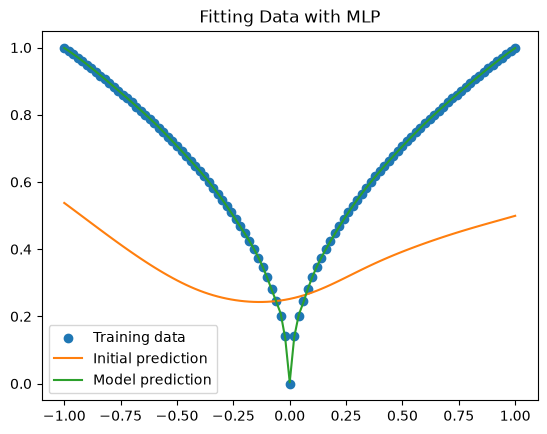

In [26]:
y_pred = forward(params, x_train)
fig, ax = plt.subplots()
ax.set_title('Fitting Data with MLP');
ax.scatter(x_train, y_train, c='tab:blue', label='Training data')
ax.plot(x_train, y_init, c='tab:orange', label='Initial prediction')
ax.plot(x_train, y_pred, c='tab:green', label='Model prediction')
ax.legend();

Compute _r2 score_

In [27]:
r2 = round(float(r2_score(y_train, y_pred)), 4)
print("R^2 Score:", r2)

R^2 Score: 1.0
